# The ranking process — a trend-only walkthrough

**Read top to bottom. Each stage produces a table used by the next stage.**

`two input tables → four trend features + outcome labels → select features`
`→ tune the ranker → calibrate the confidence gate → calibrate size → trade`

This lighter companion to [v2](harvesting_vrp_synthetic_v2.ipynb) shows its first
2021 prediction cycle. It keeps 14 indices plus learned SKIP, t−1 features for
EOD t trades, the gross downside-adjusted label, S1–S5, LambdaRank, 50 TPE trials
and the three optimizations. The model inputs contain **only four trend features**.

The lifecycle remains short 25-delta M1 put, switch new entries when front M1
has fewer than five business days left, and exit at ten business days or expiry,
whichever comes first. The small producer below fabricates cash flows directly:
**it is not an option pricer**. It deliberately makes lagged trend predictive.
Its fitted performance is a teaching artifact, not trading evidence.

The [paper](../../docs/research/papers/Harvesting_the_Volatility_Risk_Premium_A_Learning_to_Rank_Approach.md)
supplies all model/selection settings. The four trend formulas are its moving-average
features, applied to each index rather than shared SPX context. This version has
no VIX, Greeks, IV, interactions, history features or within-day feature ranks.
V2 remains the detailed source adapter and full five-year reference.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import optuna
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
from scipy.optimize import brentq
from IPython.display import display

SEED = 260824786  # Same explicitly synthetic seed as v2.
ANN, NAV0, TARGET_VOL = 252, 5_000_000., .16  # Paper settings.
HOLD, ROLL_DAYS = 10, 5  # Your trade conventions.
TRIALS, ROUNDS, PATIENCE = 50, 2000, 50  # Paper's search settings.
GAINS = np.array([0, 1, 3, 7, 15])
TICKERS = ['SPX', 'NDX', 'RUT', 'SX5E', 'DAX', 'CAC', 'FTSE',
           'SMI', 'IBEX', 'AEX', 'N225', 'HSI', 'AS51', 'TSX']
optuna.logging.set_verbosity(optuna.logging.WARNING)

## 1. The entire feature family

For each index, compute distance from its 50-day and 200-day moving averages,
the sign of their crossover, and the 21-day change of the 200-day average.
**Shift once:** the row for trading on Tuesday uses Monday's observations.
Rolling-window warm-up stays missing. No cross-ranking or standardization follows.

In [2]:
def trend_features(prices):
    ma50, ma200 = prices.rolling(50).mean(), prices.rolling(200).mean()
    values = {
        'distance_50': prices/ma50-1,
        'distance_200': prices/ma200-1,
        'cross_50_200': np.sign(ma50-ma200),
        'slope_200_21': ma200/ma200.shift(21)-1,
    }
    return pd.DataFrame({name: value.shift(1).stack(future_stack=True)
                         for name, value in values.items()}).rename_axis(['date', 'candidate'])

## 2. Small synthetic producer

This function supplies the two tables; its internals are not part of fitting.
The fake markets share a weekday calendar and third-Friday monthly expiries.
Cash flows are already **signed short-position USD P&L per dollar of entry risk**,
before entry costs. This is v2's prepared `gross_per_risk` convention, not raw
Qbit P&L. The cost is a separate nonnegative amount in the same units.

The illustrative edge, noise and tail-loss numbers below are fabricated data
parameters. A trade's fake expected P&L depends only on its entry's lagged trend.
Each path retains its original expiry and has marks from entry through exit.

In [3]:
def synthetic_inputs():
    rng = np.random.default_rng(SEED)
    calendar = pd.bdate_range('2013-01-01', pd.Timestamp('2021-12-31')+pd.offsets.BDay(HOLD))
    prices = pd.DataFrame(100*np.exp(np.cumsum(rng.normal(0, .01, (len(calendar), len(TICKERS))), axis=0)),
                          index=calendar, columns=TICKERS)
    entries = calendar[calendar < '2022-01-01']
    keys = pd.MultiIndex.from_product([entries, TICKERS], names=['date', 'candidate'])
    trend = trend_features(prices).reindex(keys)
    edge = .003 + .04*np.tanh(trend.distance_50.fillna(0).to_numpy()/.05)

    expiries = pd.date_range('2013-01-01', '2022-02-28', freq='WOM-3FRI').to_numpy()
    start = keys.get_level_values('date').to_numpy()
    front = np.searchsorted(expiries, start)
    remaining = np.busday_count(start.astype('datetime64[D]'), expiries[front].astype('datetime64[D]'))
    expiry = expiries[front+(remaining < ROLL_DAYS)]
    days_left = np.busday_count(start.astype('datetime64[D]'), expiry.astype('datetime64[D]'))
    duration = np.minimum(HOLD, days_left)
    offsets = np.arange(HOLD+1)
    mark_positions = calendar.get_indexer(start)[:, None]+offsets
    gross = edge[:, None]+rng.normal(0, .07, mark_positions.shape)
    gross -= .15*(rng.random(mark_positions.shape) < .025)  # Fake downside events.
    gross[:, 0] = 0.
    live = offsets[None, :] <= duration[:, None]
    paths = pd.DataFrame({
        'entry_date': np.broadcast_to(start[:, None], live.shape)[live],
        'candidate': np.broadcast_to(keys.get_level_values('candidate').to_numpy()[:, None], live.shape)[live],
        'secId': np.broadcast_to(np.tile(np.arange(1, len(TICKERS)+1), len(entries))[:, None], live.shape)[live],
        'expiry_date': np.broadcast_to(expiry[:, None], live.shape)[live],
        'exit_date': np.broadcast_to(calendar[calendar.get_indexer(start)+duration].to_numpy()[:, None], live.shape)[live],
        'mark_date': calendar.to_numpy()[mark_positions[live]],
        'gross': gross[live],
        'cost': np.broadcast_to(np.where(offsets == 0, .001, 0.), live.shape)[live],
    })
    return prices, paths

## 3. THE DATA BOUNDARY — replace only the next cell for real data

| Table | Required shape / units |
|---|---|
| `prices` | Full ordered research-calendar index; one column per index; positive EOD closes |
| `paths` | `entry_date,candidate,secId,expiry_date,exit_date,mark_date,gross,cost`; one row per entry/candidate/mark; integer `secId` |

Real data should already implement the same fixed-expiry/holding rule and use
the prepared USD risk-unit convention above. Export v2's `gross_per_risk` and
`cost_per_risk` as `gross` and `cost`; do **not** apply quantity, sign, FX or rtvega
normalization again. Costs are excluded from the label and included in trading.

For this compact daily example, each path has one mark per supplied calendar
session from entry to exit, including a zero-gross opening mark. Retain partial
paths; their labels remain unavailable. Prices and marks must be point-in-time
observations available by their stated EOD. Align market calendars upstream;
v2 documents the full per-market availability adapter.

To switch sources, replace the assignment below with your two prepared table
reads. Everything after this cell consumes **only these tables** and the stated
settings. There is no dependency on generator state and no hidden helper module.

In [4]:
prices, paths = synthetic_inputs()
# Real-data replacement, for example:
# prices = pd.read_parquet('prepared_daily_closes.parquet')
# paths = pd.read_parquet('prepared_trade_paths.parquet')

display(prices.head())
display(paths.head())

,SPX,NDX,RUT,SX5E,DAX,CAC,FTSE,SMI,IBEX,AEX,N225,HSI,AS51,TSX
2013-01-01,100.098667,100.517900,98.850447,101.061359,98.547577,99.829084,101.195853,98.627024,101.919250,100.821783,100.695145,99.577969,101.238068,100.617509
2013-01-02,100.879184,101.866786,98.526459,101.440160,98.670627,98.381919,100.657366,99.053129,101.877671,100.678815,99.716103,98.661807,98.882920,101.181946
2013-01-03,101.530402,103.333219,98.522259,99.879875,98.961997,97.795436,100.152426,97.649271,101.537987,100.796208,100.399604,97.957467,99.663417,102.525670
2013-01-04,103.222384,101.975051,97.303323,100.351394,99.698104,97.114364,101.192455,97.118629,101.346765,100.151424,99.955628,98.164385,99.552578,103.290728
2013-01-07,101.822730,102.753921,96.946313,100.288916,99.348869,95.732438,103.912950,98.161230,100.640674,100.801341,98.840906,98.164166,98.690923,102.677721


,entry_date,candidate,secId,expiry_date,exit_date,mark_date,gross,cost
0,2013-01-01,SPX,1,2013-01-18,2013-01-15,2013-01-01,0.000000,0.001
1,2013-01-01,SPX,1,2013-01-18,2013-01-15,2013-01-02,0.093145,0.000
2,2013-01-01,SPX,1,2013-01-18,2013-01-15,2013-01-03,0.077832,0.000
3,2013-01-01,SPX,1,2013-01-18,2013-01-15,2013-01-04,-0.059706,0.000
4,2013-01-01,SPX,1,2013-01-18,2013-01-15,2013-01-07,-0.151146,0.000


In [5]:
calendar = pd.DatetimeIndex(prices.index)
assert calendar.is_unique and calendar.is_monotonic_increasing
assert set(prices.columns) == set(paths.candidate.unique())
assert (prices.gt(0) | prices.isna()).all().all() and not np.isinf(prices.to_numpy()).any()
assert pd.api.types.is_integer_dtype(paths.secId)
assert paths.groupby('candidate').secId.nunique().eq(1).all()
assert paths.groupby('secId').candidate.nunique().eq(1).all()
assert not paths.duplicated(['entry_date', 'candidate', 'mark_date']).any()
assert paths[['entry_date', 'candidate', 'expiry_date', 'exit_date', 'mark_date']].notna().all().all()
assert paths.entry_date.isin(calendar).all() and paths.mark_date.isin(calendar).all()
assert (paths.mark_date >= paths.entry_date).all() and (paths.mark_date <= paths.exit_date).all()
assert (paths.exit_date <= paths.expiry_date).all()
assert np.isfinite(paths[['gross', 'cost']]).all().all() and paths.cost.ge(0).all()
assert paths.loc[paths.mark_date.eq(paths.entry_date), 'gross'].eq(0).all()

## 4. Outcomes become labels; they do not become features

For one trade path, let `G` be total gross P&L and `D` the square root of the
sum of squared negative daily P&Ls. The continuous outcome is `z = G/(D+1e-8)`.
This is the paper's downside-adjusted construction using v2's daily marks.
It is known only after the path finishes. An unfinished path never gets a grade.

Add SKIP to each day's query: its realized z is zero and all four trend inputs
are missing. The model learns SKIP's prediction; we never fix it to zero.
The displayed table puts **features and future outcomes side by side for inspection**;
only `X` goes into LightGBM.

In [6]:
panel = paths.assign(down2=np.minimum(paths.gross, 0)**2).groupby(['entry_date', 'candidate']).agg(
    gross=('gross', 'sum'), down2=('down2', 'sum'), first_mark=('mark_date', 'min'),
    last_mark=('mark_date', 'max'), exit_date=('exit_date', 'first'), marks=('mark_date', 'size'))
panel.index = panel.index.set_names(['date', 'candidate'])
entry_dates = panel.index.get_level_values('date')
expected = calendar.get_indexer(panel.exit_date)-calendar.get_indexer(entry_dates)+1
complete = panel.first_mark.eq(entry_dates) & panel.last_mark.eq(panel.exit_date) & panel.marks.eq(expected)
panel['z'] = (panel.gross/(np.sqrt(panel.down2)+1e-8)).where(complete)
panel['label_available'] = panel.exit_date.where(complete)
skip = pd.DataFrame(index=pd.MultiIndex.from_product([entry_dates.unique(), ['SKIP']], names=panel.index.names))
skip['z'], skip['gross'] = 0., 0.
skip['label_available'] = panel.label_available.groupby(level='date').max().reindex(entry_dates.unique()).to_numpy()
panel = pd.concat([panel, skip]).sort_index()
X = trend_features(prices).reindex(panel.index)
row_dates = panel.index.get_level_values('date')
real = panel.index.get_level_values('candidate') != 'SKIP'
display(X.join(panel[['gross', 'z', 'label_available']]).loc['2020-01-02'])

,distance_50,distance_200,cross_50_200,slope_200_21,gross,z,label_available
candidate,,,,,,,
AEX,0.022859,-0.047431,-1.0,-0.014366,0.153757,0.595139,2020-01-16
AS51,-0.031723,-0.099776,-1.0,-0.019449,-0.495610,-1.697307,2020-01-16
CAC,-0.062980,-0.118137,-1.0,-0.018263,-0.272474,-1.202471,2020-01-16
DAX,-0.058421,-0.117868,-1.0,-0.016974,-0.176008,-0.896766,2020-01-16
FTSE,0.024076,0.025282,1.0,-0.002623,0.376139,2.137859,2020-01-16
HSI,0.016033,0.026370,1.0,0.000333,0.379722,11.462953,2020-01-16
IBEX,-0.070869,-0.131549,-1.0,-0.018276,-0.224863,-0.898840,2020-01-16
N225,-0.029855,0.001829,1.0,0.003666,-0.043424,-0.302906,2020-01-16
NDX,0.016815,0.107837,1.0,0.014391,0.131638,0.763794,2020-01-16


## 5. Give each period one job

| Role | Entry dates | Used for |
|---|---|---|
| Search fitting | 2013–2019 | Fit trial models and label cutpoints |
| Hyperparameter validation | January–June 2020 | Compare trials using NDCG@1 |
| Early stopping | April–June 2020 | Choose each trial's tree count |
| Final refit | Through March 2020 | Refit with the winning hyperparameters |
| Confidence calibration | July–December 2020 | Choose the score-gap threshold |
| Prediction | 2021 | Frozen model, threshold and size |

The full query is purged if any candidate's outcome is unknown at a period's
end. V2/the paper run feature selection on the broader pre-gate history,
including validation dates; that is not fully nested hyperparameter evaluation.
This notebook shows this split explicitly rather than wrapping it in a year loop.

In [7]:
def period(start, end):
    known = panel.z.notna() & panel.label_available.lt(pd.Timestamp(end))
    whole_query_known = known.groupby(level='date').transform('all').to_numpy()
    return (row_dates >= pd.Timestamp(start)) & (row_dates < pd.Timestamp(end)) & whole_query_known


search_fit = period('2013-01-01', '2020-01-01')
validation = period('2020-01-01', '2020-07-01')
early_stop = period('2020-04-01', '2020-07-01')
refit = period('2013-01-01', '2020-04-01')
selection = period('2013-01-01', '2020-07-01')
gate = period('2020-07-01', '2021-01-01')
test = (row_dates >= pd.Timestamp('2021-01-01')) & (row_dates < pd.Timestamp('2022-01-01'))
display(pd.Series({name: row_dates[mask].nunique() for name, mask in
    [('search_fit', search_fit), ('validation', validation), ('early_stop', early_stop),
     ('refit', refit), ('selection', selection), ('gate', gate), ('test', test)]}, name='queries'))

search_fit    1816
validation     120
early_stop      55
refit         1881
selection     1946
gate           122
test           261
Name: queries, dtype: int64

## 6. Select features (S1–S5)

Even with four columns, show each decision: missingness, near-constant values,
relevance, redundancy and stability. All are candidate-specific, so relevance
is the median within-day Spearman correlation with z. SKIP is excluded here.
Spearman ranks are used **for screening only**, not as transformed model inputs.

S4 uses v2's connected correlation clusters. The paper's trend cap is five;
with four starting columns that cap cannot bind, so no group-management code is
needed. S5 uses v2's three expanding folds and two-fold survival rule.

In [8]:
def screen(mask):
    frame, target = X.loc[mask & real], panel.loc[mask & real, 'z']
    audit = pd.DataFrame({'missing': frame.isna().mean(), 'variance': frame.var(),
                          'mode_fraction': frame.apply(lambda s: s.value_counts(normalize=True).max())})
    audit['relevance'] = np.nan
    for name in frame:
        pairs = pd.concat([frame[name].rename('x'), target.rename('y')], axis=1).dropna()
        ranks = pairs.groupby(level='date').rank()
        centered = ranks-ranks.groupby(level='date').transform('mean')
        numerator = (centered.x*centered.y).groupby(level='date').sum()
        denominator = np.sqrt(centered.x.pow(2).groupby(level='date').sum()*centered.y.pow(2).groupby(level='date').sum())
        audit.loc[name, 'relevance'] = (numerator/denominator.replace(0, np.nan)).median()
    audit['reason'] = 'kept'
    audit.loc[audit.missing > .30, 'reason'] = 'S1 missing'
    audit.loc[audit.reason.eq('kept') & ((audit.variance < 1e-6) | (audit.mode_fraction > .99)), 'reason'] = 'S2 constant'
    audit.loc[audit.reason.eq('kept') & (audit.relevance.isna() | audit.relevance.abs().lt(.05)), 'reason'] = 'S3 weak'
    names = audit.index[audit.reason.eq('kept')]
    if len(names):
        adjacency = frame[names].corr(method='spearman').abs().fillna(0).to_numpy() >= .85
        np.fill_diagonal(adjacency, True)
        _, cluster = connected_components(csr_matrix(adjacency), directed=False)
        for label in np.unique(cluster):
            members = names[cluster == label]
            winner = min(members, key=lambda c: (-abs(audit.at[c, 'relevance']), audit.at[c, 'missing'], c))
            audit.loc[members.difference([winner]), 'reason'] = 'S4 redundant'
    return audit


audit = screen(selection)
survival = pd.Series(0, index=X.columns)
for fold in np.array_split(row_dates[selection].unique(), 3):
    known = panel.z.notna() & panel.label_available.le(fold[-1])
    fold_mask = selection & (row_dates <= fold[-1]) & known.groupby(level='date').transform('all').to_numpy()
    survival += screen(fold_mask).reason.eq('kept').astype(int)
audit['folds'] = survival
audit.loc[audit.reason.eq('kept') & audit.folds.lt(2), 'reason'] = 'S5 unstable'
features = audit.index[audit.reason.eq('kept')].tolist()
if not features:
    raise ValueError('No trend features survive S1–S5; do not silently bypass selection.')
display(audit)

,missing,variance,mode_fraction,relevance,reason,folds
distance_50,0.025694,0.001620,0.000038,0.665934,kept,3
distance_200,0.102775,0.006151,0.000041,0.450549,kept,2
cross_50_200,0.102775,0.998959,0.516446,0.143223,kept,2
slope_200_21,0.113566,0.000199,0.000041,0.195604,kept,2


## 7. Turn z into five training grades

Fit the 10/40/60/90% cutpoints on **search-fit real candidates only**. Freeze
them for validation. These are pooled time-series cutpoints, not daily ranks.
The refit later gets its own fitting-only cutpoints. A date is one ranking query;
the group-size array tells LightGBM where each query ends.

In [9]:
def grade_cuts(mask):
    return panel.loc[mask & real, 'z'].quantile([.10, .40, .60, .90]).to_numpy()


def grade(z, cuts):
    return np.searchsorted(cuts, np.asarray(z), side='left').astype(np.int32)


def dataset(mask, cuts, reference=None):
    frame = X.loc[mask, features]
    groups = frame.groupby(level='date', sort=False).size().to_numpy()
    return lgb.Dataset(frame.to_numpy(), label=grade(panel.loc[mask, 'z'], cuts), group=groups,
                       feature_name=features, reference=reference, params={'feature_pre_filter': False})


cuts = grade_cuts(search_fit)
display(pd.Series(cuts, index=['10%', '40%', '60%', '90%'], name='z cutpoint'))
example = X.loc['2020-01-02', features].join(panel.loc['2020-01-02', ['z']])
example['grade'] = grade(example.z, cuts)
display(example)

10%   -1.783739
40%   -0.553446
60%    0.560245
90%    6.036280
Name: z cutpoint, dtype: float64

,distance_50,distance_200,cross_50_200,slope_200_21,z,grade
candidate,,,,,,
AEX,0.022859,-0.047431,-1.0,-0.014366,0.595139,3
AS51,-0.031723,-0.099776,-1.0,-0.019449,-1.697307,1
CAC,-0.062980,-0.118137,-1.0,-0.018263,-1.202471,1
DAX,-0.058421,-0.117868,-1.0,-0.016974,-0.896766,1
FTSE,0.024076,0.025282,1.0,-0.002623,2.137859,3
HSI,0.016033,0.026370,1.0,0.000333,11.462953,4
IBEX,-0.070869,-0.131549,-1.0,-0.018276,-0.898840,1
N225,-0.029855,0.001829,1.0,0.003666,-0.302906,2
NDX,0.016815,0.107837,1.0,0.014391,0.763794,3


## 8. Optimization 1 — fit the ranker

Tune the same eight hyperparameters as v2 for 50 TPE trials. Each trial trains
on `search_fit`, early-stops on `early_stop`, and is compared on the full
`validation` period using NDCG@1. Gains are `[0,1,3,7,15]`; metrics are NDCG@1/@3;
LambdaRank truncation is five. The final model refits through March 2020.

In [10]:
base_params = dict(objective='lambdarank', metric='ndcg', ndcg_eval_at=[1, 3],
    label_gain=GAINS.tolist(), lambdarank_truncation_level=5, verbosity=-1,
    deterministic=True, force_col_wise=True, feature_pre_filter=False,
    seed=SEED+2021, num_threads=int(os.environ.get('OMP_NUM_THREADS', 0)))
train_set = dataset(search_fit, cuts)
stop_set = dataset(early_stop, cuts, train_set)


def objective(trial):
    params = dict(base_params,
        num_leaves=trial.suggest_int('num_leaves', 16, 256, log=True),
        learning_rate=trial.suggest_float('learning_rate', .01, .10, log=True),
        min_data_in_leaf=trial.suggest_int('min_data_in_leaf', 20, 200, log=True),
        feature_fraction=trial.suggest_float('feature_fraction', .5, 1.),
        bagging_fraction=trial.suggest_float('bagging_fraction', .5, 1.),
        bagging_freq=trial.suggest_int('bagging_freq', 0, 10),
        lambda_l1=trial.suggest_float('lambda_l1', 1e-3, 10., log=True),
        lambda_l2=trial.suggest_float('lambda_l2', 1e-3, 10., log=True))
    trial_model = lgb.train(params, train_set, num_boost_round=ROUNDS, valid_sets=[stop_set],
        callbacks=[lgb.early_stopping(PATIENCE, first_metric_only=True, verbose=False)])
    scores = pd.DataFrame({'score': trial_model.predict(X.loc[validation, features].to_numpy()),
                            'gain': GAINS[grade(panel.loc[validation, 'z'], cuts)]}, index=X.index[validation])
    top = scores.sort_values('score', ascending=False, kind='stable').groupby(level='date').head(1)
    actual = top.gain.droplevel('candidate').sort_index()
    ideal = scores.gain.groupby(level='date').max()
    return (actual/ideal.replace(0, np.nan)).fillna(1.).mean()


study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED+2021))
study.optimize(objective, n_trials=TRIALS)
refit_cuts = grade_cuts(refit)
train_set = dataset(refit, refit_cuts)
stop_set = dataset(early_stop, refit_cuts, train_set)
model = lgb.train(dict(base_params, **study.best_params), train_set, num_boost_round=ROUNDS,
    valid_sets=[stop_set], callbacks=[lgb.early_stopping(PATIENCE, first_metric_only=True, verbose=False)])
display(pd.Series(study.best_params, name='chosen setting'))
print('Validation NDCG@1:', study.best_value, '| final trees:', model.best_iteration)

num_leaves          16.000000
learning_rate        0.063598
min_data_in_leaf    37.000000
feature_fraction     0.659866
bagging_fraction     0.744147
bagging_freq         5.000000
lambda_l1            0.001205
lambda_l2            0.176485
Name: chosen setting, dtype: float64

Validation NDCG@1: 0.7487301587301587 | final trees: 1


## 9. Scores → top candidate → confidence gap

Scores are relative ranking values, not probabilities. For each date, keep the
highest-scoring candidate and compute `gap = top score − runner-up score`.
SKIP participates normally. Candidate names are used only to break exact ties.

In [11]:
def top_candidates(mask):
    scores = X.loc[mask, []].copy()
    scores['score'] = model.predict(X.loc[mask, features].to_numpy())
    ranked = scores.reset_index().sort_values(['date', 'score', 'candidate'], ascending=[True, False, True])
    groups = ranked.groupby('date', sort=False)
    top = groups.head(1).set_index('date')
    runner_up = groups.nth(1).set_index('date')
    top['gap'] = top.score-runner_up.score.reindex(top.index)
    return top


gate_top = top_candidates(gate)
display(gate_top.head())

,candidate,score,gap
date,,,
2020-07-01,HSI,0.096275,0.0
2020-07-02,FTSE,0.096275,0.0
2020-07-03,HSI,0.096275,0.0
2020-07-06,AEX,0.096275,0.0
2020-07-07,AEX,0.096275,0.0


## 10. One ledger for the gate, sizing and test

Rows of the cash-flow matrix are **mark dates**; columns are **entry dates**.
It contains the selected trades' net P&L per dollar of entry risk. Multiplying
by entry allocations gives daily portfolio P&L, including overlapping cohorts.

Opening a cohort at size `a` allocates `a × previous NAV` risk units. That cohort
keeps its allocation until exit. SKIP opens nothing; it does not close earlier
trades. Keep zero-P&L dates in the calendar and settle the final January tail.

In [12]:
def cash_matrix(top, dates):
    choices = top.reset_index().rename(columns={'date': 'entry_date'})[['entry_date', 'candidate']]
    selected = choices.merge(paths, on=['entry_date', 'candidate'], validate='one_to_many')
    rows, columns = dates.get_indexer(selected.mark_date), dates.get_indexer(selected.entry_date)
    visible = (rows >= 0) & (columns >= 0)
    return csr_matrix(((selected.gross-selected.cost).to_numpy()[visible],
                       (rows[visible], columns[visible])), shape=(len(dates), len(dates)))


def simulate(matrix, admitted, size):
    allocations, returns, nav = np.zeros(matrix.shape[0]), [], NAV0
    for day in range(matrix.shape[0]):
        before = nav
        if admitted[day]:
            allocations[day] = size*before
        left, right = matrix.indptr[day:day+2]
        pnl = matrix.data[left:right] @ allocations[matrix.indices[left:right]]
        nav += pnl
        if not np.isfinite(nav) or nav <= 0:
            raise ValueError('Portfolio became insolvent')
        returns.append((pnl, nav, pnl/before, allocations[day]))
    return pd.DataFrame(returns, columns=['pnl', 'nav', 'return', 'entry_risk'])


def metrics(returns):
    r = np.asarray(returns, dtype=float)
    if not np.isfinite(r).all() or np.any(r <= -1):
        raise ValueError('Metrics require finite returns above -100%')
    annual_return = np.expm1(ANN*np.log1p(r).mean())
    vol = np.sqrt(ANN)*r.std(ddof=1)
    downside = np.sqrt(ANN*np.minimum(r, 0).dot(np.minimum(r, 0))/len(r))
    sortino = annual_return/downside if downside else (np.inf if annual_return > 0 else np.nan)
    return pd.Series({'annual_return': annual_return, 'annual_vol': vol, 'Sortino': sortino})

## 11. Optimization 2 — calibrate the confidence gate

Use July–December 2020 predictions and completed outcomes. Evaluate **every
observed score gap plus zero**, as requested for v2. Admit only real candidates
whose gap reaches the threshold. Choose the best held-out Sortino; ties favor
the smaller threshold. Each admitted cohort has a fixed $1 entry-risk allocation
for this comparison, with daily P&L divided by the paper's $5M starting NAV.

In [13]:
gate_dates = calendar[(calendar >= '2020-07-01') & (calendar < '2021-01-01')]
gate_matrix = cash_matrix(gate_top, gate_dates)
gate_curve = []
for threshold in np.unique(np.r_[0., gate_top.gap]):
    admit = (gate_top.candidate.ne('SKIP') & gate_top.gap.ge(threshold)).reindex(gate_dates, fill_value=False)
    returns = np.asarray(gate_matrix @ admit.to_numpy(dtype=float)).ravel()/NAV0
    gate_curve.append((threshold, int(admit.sum()), metrics(returns)['Sortino']))
gate_curve = pd.DataFrame(gate_curve, columns=['threshold', 'trades', 'Sortino'])
valid = gate_curve.dropna(subset=['Sortino']).sort_values(['Sortino', 'threshold'], ascending=[False, True])
threshold = float(valid.iloc[0].threshold) if len(valid) else 0.
gate_status = 'identified' if len(valid) else 'unidentified: no nonzero gated path'
display(valid.head())
print('Chosen threshold:', threshold, '|', gate_status)

,threshold,trades,Sortino
5,0.050764,4,149.721953
0,0.000000,122,79.395135
1,0.012025,53,54.280603
2,0.015082,15,39.054882
3,0.023657,11,22.704515


Chosen threshold: 0.05076436384269118 | identified


## 12. Optimization 3 — calibrate risk-unit size

With the model and gate fixed, use **refit-training predictions**, as in v2,
to solve for the common size `a` producing 16% annualized training volatility.
This is your approved Qbit risk-unit adaptation of the paper's sizing step.
The bracket starts from measured unit-risk volatility and expands as needed;
there is no chosen leverage ceiling. An all-cash sample cannot reach the target.

In [14]:
training_top = top_candidates(refit)
training_dates = calendar[(calendar >= '2013-01-01') & (calendar < '2020-04-01')]
training_matrix = cash_matrix(training_top, training_dates)
training_admit = (training_top.candidate.ne('SKIP') & training_top.gap.ge(threshold)).reindex(training_dates, fill_value=False).to_numpy()
unit_vol = np.sqrt(ANN)*np.asarray(training_matrix @ training_admit.astype(float)).std(ddof=1)
size_evaluations = []


def size_error(size):
    volatility = metrics(simulate(training_matrix, training_admit, size)['return']).annual_vol
    size_evaluations.append((size, volatility))
    return volatility-TARGET_VOL


size = 0.
if unit_vol > 0:
    upper = TARGET_VOL/unit_vol
    while size_error(upper) < 0:
        upper *= 2
    size = brentq(size_error, 0., upper)
display(pd.DataFrame(size_evaluations, columns=['size', 'training_volatility']))
print('Frozen risk fraction per new cohort:', size)

,size,training_volatility
0,0.174681,0.144731
1,0.349362,0.269238
2,0.000000,0.000000
3,0.349362,0.269238
4,0.207615,0.169414
5,0.194991,0.160029
6,0.194951,0.160000
7,0.194951,0.160000
8,0.194951,0.160000


Frozen risk fraction per new cohort: 0.19495147174905245


## 13. Use the frozen decisions on 2021

This cell performs no fitting. Choose the daily top candidate, apply the fixed
gate, open the allowed cohort at the fixed size, and mark all active trades.
The tail after 2021 contains settlements only. The performance table is an
**output**, not a strategy-performance feature fed back into the model.

,candidate,score,gap,admitted
date,,,,
2021-01-01,SX5E,0.096275,0.012025,False
2021-01-04,SX5E,0.096275,0.027107,False
2021-01-05,SX5E,0.096275,0.027107,False
2021-01-06,SX5E,0.084250,0.015082,False
2021-01-07,CAC,0.084250,0.000000,False
2021-01-08,CAC,0.084250,0.000000,False
2021-01-11,CAC,0.084250,0.015082,False
2021-01-12,CAC,0.084250,0.015082,False
2021-01-13,NDX,0.084250,0.015082,False


,synthetic 2021
annual_return,0.192574
annual_vol,0.080290
Sortino,6.710909


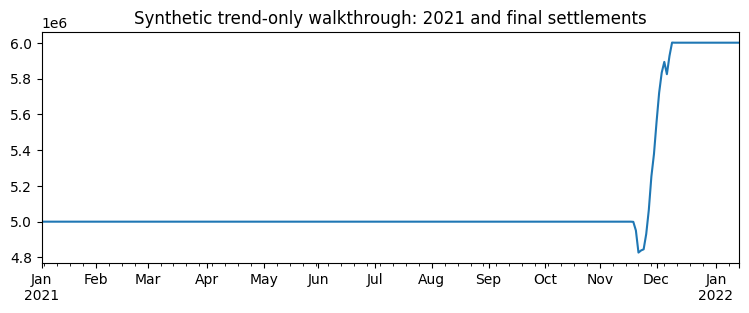

In [15]:
decisions = top_candidates(test)
decisions['admitted'] = decisions.candidate.ne('SKIP') & decisions.gap.ge(threshold)
test_dates = calendar[calendar >= '2021-01-01']
test_matrix = cash_matrix(decisions, test_dates)
admitted = decisions.admitted.reindex(test_dates, fill_value=False).to_numpy()
ledger = simulate(test_matrix, admitted, size).set_axis(test_dates)
display(decisions.head(10))
display(metrics(ledger.loc[ledger.index < '2022-01-01', 'return']).to_frame('synthetic 2021'))
ledger.nav.plot(title='Synthetic trend-only walkthrough: 2021 and final settlements', figsize=(9, 3))
plt.show()

## 14. Compact checks

These check the causal boundaries and cash-flow accounting, not the synthetic
strategy's profitability. To explore the process, inspect `audit`, `cuts`,
`study.best_params`, `gate_curve`, `size_evaluations`, `decisions` and `ledger`.

In [16]:
assert X.columns.tolist() == ['distance_50', 'distance_200', 'cross_50_200', 'slope_200_21']
assert X.loc[~real].isna().all().all() and panel.loc[~real, 'z'].eq(0).all()
assert panel.index.is_unique and panel.index.is_monotonic_increasing
assert len(study.trials) == TRIALS and model.params['objective'] == 'lambdarank'
assert model.params['label_gain'] == GAINS.tolist()
assert panel.loc[search_fit, 'label_available'].lt('2020-01-01').all()
assert panel.loc[gate, 'label_available'].lt('2021-01-01').all()
assert set(gate_curve.threshold) == set(np.r_[0., gate_top.gap])
if size > 0:
    assert np.isclose(metrics(simulate(training_matrix, training_admit, size)['return']).annual_vol, TARGET_VOL)
np.testing.assert_allclose(test_matrix @ ledger.entry_risk.to_numpy(), ledger.pnl)
assert np.isclose(ledger.nav.iloc[-1], NAV0+ledger.pnl.sum())
assert ledger.loc[ledger.index >= '2022-01-01', 'entry_risk'].eq(0).all()
# Changing day t and future prices cannot change a feature at or before t.
changed = prices.copy()
changed.loc['2021-06-01':] *= 2
pd.testing.assert_frame_equal(trend_features(changed).loc[:'2021-06-01'],
                              trend_features(prices).loc[:'2021-06-01'])
# A second-day SKIP still realizes yesterday's cohort's P&L.
toy = csr_matrix(np.array([[-.01, 0.], [.02, 0.]]))
toy_ledger = simulate(toy, [True, False], .1)
np.testing.assert_allclose(toy_ledger.pnl, [-.001*NAV0, .002*NAV0])
print('PASS: trend-only inputs, t−1 timing, completed labels, 50 trials, gate, size and overlapping ledger.')

PASS: trend-only inputs, t−1 timing, completed labels, 50 trials, gate, size and overlapping ledger.
